In [1]:
!pip install -q resemblyzer soundfile 2>&1 | tail -3

REPO_SHA = "06b9e82"
!rm -rf /kaggle/working/srib
!git clone https://github.com/MalayM09/SRIB.git /kaggle/working/srib
!cd /kaggle/working/srib && git checkout $REPO_SHA

import sys, os
sys.path.insert(0, "/kaggle/working/srib/code")
os.chdir("/kaggle/working/srib/code")
print("cwd:", os.getcwd())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 770.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 52.2 MB/s eta 0:00:00
Cloning into '/kaggle/working/srib'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 71 (delta 8), reused 70 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 1.18 MiB | 6.05 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Note: switching to '06b9e82'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-n

In [2]:
from pathlib import Path

VOX_ROOT   = Path("/kaggle/input/datasets/namhocayai/voxceleb1")
VOX_DEV    = VOX_ROOT / "vox1_dev_wav" / "wav"
VOX_TEST   = VOX_ROOT / "vox1_test_wav" / "wav"
TRIAL_FILE = VOX_ROOT / "veri_test2.txt"

dev_spks  = sorted(d for d in VOX_DEV.iterdir() if d.name.startswith("id"))
test_spks = sorted(d for d in VOX_TEST.iterdir() if d.name.startswith("id"))
print(f"dev speakers : {len(dev_spks)}")
print(f"test speakers: {len(test_spks)}")

with open(TRIAL_FILE) as f:
    trials_raw = [l.strip().split() for l in f if l.strip()]
print(f"trial pairs  : {len(trials_raw):,}")
print(f"sample trial : {trials_raw[0]}")

# Verify the test WAVs resolve
first_rel = trials_raw[0][1]
full = VOX_TEST / first_rel
print(f"test wav exists: {full.exists()}  ({full})")


dev speakers : 1211
test speakers: 40
trial pairs  : 41,397
sample trial : ['1', 'id10270/x6uYqmx31kE/00001.wav', 'id10270/8jEAjG6SegY/00008.wav']
test wav exists: True  (/kaggle/input/datasets/namhocayai/voxceleb1/vox1_test_wav/wav/id10270/x6uYqmx31kE/00001.wav)


In [3]:
import numpy as np
import torch
from resemblyzer import VoiceEncoder

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
teacher = VoiceEncoder(device=device)

wav = np.random.randn(48000).astype(np.float32)
emb = teacher.embed_utterance(wav)
print(f"teacher embedding: shape={emb.shape}, L2={np.linalg.norm(emb):.3f}")
print("teacher OK")


device: cpu
Loaded the voice encoder model on cpu in 0.03 seconds.
teacher embedding: shape=(256,), L2=1.000
teacher OK


In [4]:
import random

random.seed(1337)
TARGET_SPEAKERS   = 100
UTTS_PER_SPEAKER  = 5

chosen = random.sample(dev_spks, TARGET_SPEAKERS)

train_manifest = []
for spk_dir in chosen:
    wavs = list(spk_dir.rglob("*.wav"))
    if len(wavs) < UTTS_PER_SPEAKER:
        continue
    for w in random.sample(wavs, UTTS_PER_SPEAKER):
        train_manifest.append({"speaker_id": spk_dir.name, "path": str(w)})

print(f"training manifest: {len(train_manifest)} utterances "
      f"from {len(set(m['speaker_id'] for m in train_manifest))} speakers")
print(f"sample: {train_manifest[0]}")


training manifest: 500 utterances from 100 speakers
sample: {'speaker_id': 'id11133', 'path': '/kaggle/input/datasets/namhocayai/voxceleb1/vox1_dev_wav/wav/id11133/_KmGeX8nyck/00002.wav'}


In [5]:
import soundfile as sf
from tqdm import tqdm

SAMPLE_RATE = 16000
teacher_embs = np.zeros((len(train_manifest), 256), dtype=np.float32)

for i, m in enumerate(tqdm(train_manifest, desc="teacher embeds")):
    wav, sr = sf.read(m["path"])
    if wav.ndim > 1:
        wav = wav[:, 0]
    wav = wav.astype(np.float32)
    assert sr == SAMPLE_RATE, f"expected 16 kHz, got {sr}"
    teacher_embs[i] = teacher.embed_utterance(wav)

np.save("/kaggle/working/teacher_embs.npy", teacher_embs)
print(f"teacher embeddings: shape={teacher_embs.shape}, "
      f"mean L2={np.linalg.norm(teacher_embs, axis=1).mean():.3f}")


teacher embeds: 100%|██████████| 500/500 [01:02<00:00,  8.03it/s]

teacher embeddings: shape=(500, 256), mean L2=1.000


In [6]:
import torch.nn as nn
import torch.nn.functional as F
import torchaudio

from src.model import BCResNet8, LearnablePCEN


class MelFrontend(nn.Module):
    def __init__(self, n_mels=40, sample_rate=16000, use_pcen=True):
        super().__init__()
        self.melspec = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate, n_fft=512, win_length=400,
            hop_length=160, n_mels=n_mels, f_min=20.0,
            f_max=sample_rate // 2, power=2.0,
        )
        self.use_pcen = use_pcen
        if use_pcen:
            self.pcen = LearnablePCEN(n_mels)
        self.eps = 1e-6

    def forward(self, wav):
        mel = self.melspec(wav)
        return self.pcen(mel) if self.use_pcen else torch.log(mel + self.eps)


class AttnStatPool(nn.Module):
    """Attentive statistics pooling over time (B,D,T) -> (B, 2D)."""
    def __init__(self, in_dim):
        super().__init__()
        self.attn = nn.Conv1d(in_dim, in_dim, 1)

    def forward(self, x):
        alpha = F.softmax(self.attn(x), dim=-1)
        mean  = (alpha * x).sum(dim=-1)
        var   = (alpha * x ** 2).sum(dim=-1) - mean ** 2
        std   = torch.sqrt(var.clamp(min=1e-6))
        return torch.cat([mean, std], dim=-1)


class SVStudent(nn.Module):
    def __init__(self, n_mels=40, emb_dim=256, use_pcen=True, sample_rate=16000):
        super().__init__()
        self.frontend = MelFrontend(n_mels, sample_rate, use_pcen)
        self.trunk    = BCResNet8(n_mels=n_mels)
        C = self.trunk.out_channels
        self.pool     = AttnStatPool(C)
        self.proj     = nn.Linear(2 * C, emb_dim)

    def forward(self, wav):
        spec  = self.frontend(wav)                 # (B, F, T')
        feats = self.trunk(spec.unsqueeze(1))      # (B, C, F'', T'')
        feats = feats.mean(dim=2)                  # (B, C, T'') — avg over freq
        pooled = self.pool(feats)                  # (B, 2C)
        emb    = self.proj(pooled)                 # (B, 256)
        return F.normalize(emb, dim=-1)


model = SVStudent().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"student params: {n_params/1e3:.1f}K")

# Sanity forward
wav = torch.randn(2, 32000, device=device)
out = model(wav)
print(f"output: shape={tuple(out.shape)}, L2={out.norm(dim=-1).mean().item():.3f}")


student params: 384.3K
output: shape=(2, 256), L2=1.000


In [7]:
import time
from torch.utils.data import Dataset, DataLoader


class SVTrainDataset(Dataset):
    def __init__(self, manifest, teacher_embs, clip_len=32000):
        self.manifest = manifest
        self.teacher_embs = teacher_embs
        self.clip_len = clip_len

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        m = self.manifest[idx]
        wav, _ = sf.read(m["path"])
        if wav.ndim > 1:
            wav = wav[:, 0]
        wav = wav.astype(np.float32)
        if len(wav) < self.clip_len:
            wav = np.pad(wav, (0, self.clip_len - len(wav)))
        else:
            start = np.random.randint(0, len(wav) - self.clip_len + 1)
            wav = wav[start:start + self.clip_len]
        return torch.from_numpy(wav), torch.from_numpy(self.teacher_embs[idx])


train_ds     = SVTrainDataset(train_manifest, teacher_embs)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=2, drop_last=True)

EPOCHS     = 30
optimizer  = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=len(train_loader) * EPOCHS
)

history = []
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    loss_sum, n = 0.0, 0
    for wav, t_emb in train_loader:
        wav = wav.to(device); t_emb = t_emb.to(device)
        s_emb = model(wav)
        loss  = 1 - F.cosine_similarity(s_emb, t_emb, dim=-1).mean()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        scheduler.step()
        loss_sum += loss.item() * wav.size(0); n += wav.size(0)
    avg = loss_sum / n
    dt  = time.time() - t0
    history.append({"epoch": epoch, "loss": avg, "wall_s": dt})
    print(f"ep{epoch:>2} | loss={avg:.4f} | {dt:.1f}s")

torch.save({"model": model.state_dict()}, "/kaggle/working/sv_student.pt")
print(f"\nsaved → /kaggle/working/sv_student.pt")


ep 1 | loss=0.4233 | 19.1s
ep 2 | loss=0.2531 | 21.2s
ep 3 | loss=0.2445 | 21.1s
ep 4 | loss=0.2418 | 21.0s
ep 5 | loss=0.2407 | 21.1s
ep 6 | loss=0.2391 | 21.0s
ep 7 | loss=0.2360 | 21.0s
ep 8 | loss=0.2316 | 20.7s
ep 9 | loss=0.2270 | 21.2s
ep10 | loss=0.2256 | 21.6s
ep11 | loss=0.2239 | 21.2s
ep12 | loss=0.2226 | 21.0s
ep13 | loss=0.2208 | 21.2s
ep14 | loss=0.2214 | 21.3s
ep15 | loss=0.2205 | 21.2s
ep16 | loss=0.2209 | 21.1s
ep17 | loss=0.2192 | 20.9s
ep18 | loss=0.2179 | 20.8s
ep19 | loss=0.2179 | 21.5s
ep20 | loss=0.2172 | 21.1s
ep21 | loss=0.2168 | 21.0s
ep22 | loss=0.2163 | 21.0s
ep23 | loss=0.2157 | 21.1s
ep24 | loss=0.2155 | 21.6s
ep25 | loss=0.2154 | 21.0s
ep26 | loss=0.2157 | 20.7s
ep27 | loss=0.2147 | 20.9s
ep28 | loss=0.2152 | 21.0s
ep29 | loss=0.2150 | 20.5s
ep30 | loss=0.2148 | 21.1s

saved → /kaggle/working/sv_student.pt


In [9]:
# Diagnose malformed rows first
bad = [row for row in trials_raw if len(row) != 3]
print(f"malformed rows: {len(bad)}  (skipping these)")
if bad[:3]:
    print(f"sample malformed: {bad[:3]}")

# Rebuild a clean trials list
trials = [(row[0], row[1], row[2]) for row in trials_raw if len(row) >= 3]
print(f"valid trials: {len(trials):,}")

model.eval()
unique_utts = set()
for lbl, p1, p2 in trials:
    unique_utts.add(p1); unique_utts.add(p2)
print(f"unique utts to embed: {len(unique_utts):,}")

utt_embs = {}
missing = 0
for rel in tqdm(sorted(unique_utts), desc="student embeds"):
    full = VOX_TEST / rel
    if not full.is_file():
        missing += 1
        continue
    wav, sr = sf.read(str(full))
    if wav.ndim > 1:
        wav = wav[:, 0]
    wav = wav.astype(np.float32)
    if len(wav) < 16000:
        wav = np.pad(wav, (0, 16000 - len(wav)))
    with torch.no_grad():
        emb = model(torch.from_numpy(wav).unsqueeze(0).to(device)).squeeze(0).cpu().numpy()
    utt_embs[rel] = emb

print(f"embedded: {len(utt_embs):,}  missing: {missing}")


malformed rows: 2  (skipping these)
sample malformed: [['0', 'id10290/HYiqXC0B3iY/00004.wav', 'id10306/XcXDiYWIS6E/00001.wav', 'id10307/wtqPC9vEZ0M/00002.wav'], ['id10273/8cfyJEV7hP8/00028.wav']]
valid trials: 41,396
unique utts to embed: 4,708


student embeds: 100%|██████████| 4708/4708 [06:38<00:00, 11.81it/s]

embedded: 4,708  missing: 0


pairs evaluated: 41,396
EER            : 28.67%
EER threshold  : 0.9906


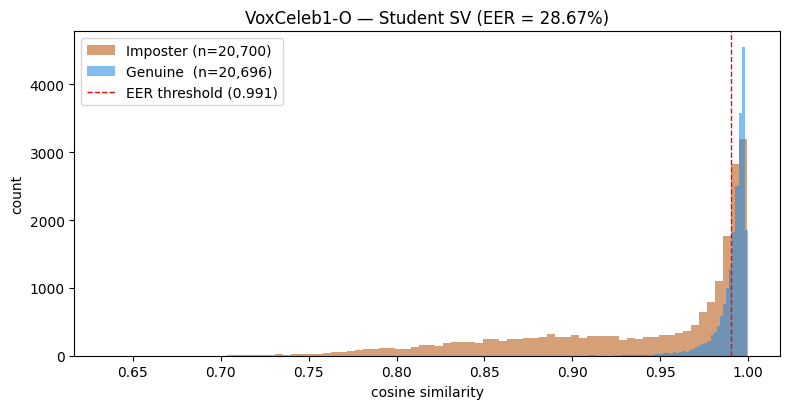

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

scores, labels = [], []
for lbl, p1, p2 in trials:
    if p1 not in utt_embs or p2 not in utt_embs:
        continue
    s = float(np.dot(utt_embs[p1], utt_embs[p2]))
    scores.append(s); labels.append(int(lbl))
scores = np.array(scores); labels = np.array(labels)

fpr, tpr, thresholds = roc_curve(labels, scores)
fnr = 1 - tpr
idx = int(np.argmin(np.abs(fpr - fnr)))
eer = (fpr[idx] + fnr[idx]) / 2
thr = thresholds[idx]

print(f"pairs evaluated: {len(scores):,}")
print(f"EER            : {eer*100:.2f}%")
print(f"EER threshold  : {thr:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
genuine  = scores[labels == 1]
imposter = scores[labels == 0]
ax.hist(imposter, bins=80, alpha=0.55, color="#B45309", label=f"Imposter (n={len(imposter):,})")
ax.hist(genuine,  bins=80, alpha=0.55, color="#1E88E5", label=f"Genuine  (n={len(genuine):,})")
ax.axvline(thr, color="red", ls="--", lw=1, label=f"EER threshold ({thr:.3f})")
ax.set_xlabel("cosine similarity")
ax.set_ylabel("count")
ax.set_title(f"VoxCeleb1-O — Student SV (EER = {eer*100:.2f}%)")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/sv_score_histogram.png", dpi=200, bbox_inches="tight")
plt.show()


In [11]:
import csv, json

with open("/kaggle/working/sv_trial_scores.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["label", "score"])
    for l, s in zip(labels.tolist(), scores.tolist()):
        w.writerow([l, s])

summary = {
    "step": "A — SV branch proof-of-concept",
    "teacher": "resemblyzer (GE2E-LSTM, 256-dim)",
    "training_subset": {
        "n_speakers": len(set(m["speaker_id"] for m in train_manifest)),
        "n_utterances": len(train_manifest),
    },
    "student_params_k": round(n_params / 1e3, 1),
    "training": {"epochs": EPOCHS, "final_loss": history[-1]["loss"]},
    "evaluation": {
        "test_pairs": int(len(scores)),
        "EER_percent": round(eer * 100, 2),
        "EER_threshold": round(float(thr), 4),
    },
}
json.dump(summary, open("/kaggle/working/sv_summary.json", "w"), indent=2)

print("=" * 60)
print("STEP A — SV PROOF-OF-CONCEPT RESULTS")
print("=" * 60)
print(f"Student params       : {n_params/1e3:.1f}K")
print(f"Training utterances  : {len(train_manifest)} from {len(set(m['speaker_id'] for m in train_manifest))} speakers")
print(f"Final distillation loss: {history[-1]['loss']:.4f}")
print(f"Trial pairs evaluated : {len(scores):,}")
print(f"VoxCeleb1-O EER      : {eer*100:.2f}%")
print()
print("Go / no-go thresholds:")
print("  ≤ 5 %   GREEN  — proceed to Step B (FiLM study)")
print("  5–10 %  YELLOW — workable; try more data / AAM head")
print("  10–15 % ORANGE — diagnostic needed (run standalone SV to isolate)")
print("  > 15 %  RED    — consider pivot to PS02")

!tar czf /kaggle/working/sv_poc_results.tar.gz \
    /kaggle/working/sv_student.pt \
    /kaggle/working/sv_score_histogram.png \
    /kaggle/working/sv_trial_scores.csv \
    /kaggle/working/sv_summary.json \
    /kaggle/working/teacher_embs.npy
!ls -lh /kaggle/working/sv_poc_results.tar.gz


STEP A — SV PROOF-OF-CONCEPT RESULTS
Student params       : 384.3K
Training utterances  : 500 from 100 speakers
Final distillation loss: 0.2148
Trial pairs evaluated : 41,396
VoxCeleb1-O EER      : 28.67%

Go / no-go thresholds:
  ≤ 5 %   GREEN  — proceed to Step B (FiLM study)
  5–10 %  YELLOW — workable; try more data / AAM head
  10–15 % ORANGE — diagnostic needed (run standalone SV to isolate)
  > 15 %  RED    — consider pivot to PS02
tar: Removing leading `/' from member names
tar: Removing leading `/' from hard link targets
-rw-r--r-- 1 root root 2.2M Apr 23 20:43 /kaggle/working/sv_poc_results.tar.gz
